# Preprocesamiento de datos de ventas de Pines NFC
### Este notebook tiene como objetivo hacer el procesamiento inicial del data_set de ventas del emprenmiento de ventas de productos de accesorios con nfc


### 1.Importación de datos, librerias e inspección inicial del dataset

In [207]:
## traer los paquetes o librerias 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sbn
import sqlite3

### 1.1 conversión de datos formato correcto de acuerdo con los resultados de raw_data.info donde se idenfica que no hay valores vacios en nuestra infomración

In [208]:
#importar datos 
raw_data = pd.read_csv("data/nfc_sales_synthetic.csv")

print(raw_data.head())
raw_data.info()
print(raw_data.shape)

                        fecha      mes dia_semana  semana           producto  \
0  2023-01-03 18:19:37.180995  2023-01    Tuesday       1   Pulsera NFC Plus   
1  2023-01-04 00:21:42.562036  2023-01  Wednesday       1        Tarjeta NFC   
2  2023-01-04 19:06:02.586531  2023-01  Wednesday       1        Tarjeta NFC   
3  2023-01-06 00:31:05.391784  2023-01     Friday       1  Brazalete Premium   
4  2023-01-08 20:36:44.190016  2023-01     Sunday       1        Tarjeta NFC   

   precio_unitario  descuento_pct  monto_venta  costo_unitario  ganancia  \
0               45              0         45.0              18      27.0   
1               25             10         22.5               8      14.5   
2               25              0         25.0               8      17.0   
3               60              0         60.0              22      38.0   
4               25              0         25.0               8      17.0   

   margen_pct      canal        ciudad  
0       60.00  Instag

In [209]:
print("isna")
print(raw_data.isna().sum())
    #1.1 Conversión de fecha a objetct a tipo datetime
raw_data['fecha'] = pd.to_datetime(raw_data['fecha'])
print(raw_data['fecha'].dtype)

    #El formato de mes y año no es facil para algun tratamiento de datos  asi que se trasnforman en lo que se esta necestiando 
pre_proccessed_data=raw_data.drop('mes',axis=1)
pre_proccessed_data['año'] = raw_data['fecha'].dt.year


pre_proccessed_data['mes_numero'] = raw_data['fecha'].dt.month
print(len(pre_proccessed_data['mes_numero'].value_counts()))
print(len(pre_proccessed_data['semana'].value_counts()))

#revisión de duplicados 
print("duplicados")
print(pre_proccessed_data.duplicated().sum())
# no hay duplicados de acuerdo con lo obtenido 

isna
fecha              0
mes                0
dia_semana         0
semana             0
producto           0
precio_unitario    0
descuento_pct      0
monto_venta        0
costo_unitario     0
ganancia           0
margen_pct         0
canal              0
ciudad             0
dtype: int64
datetime64[ns]
12
51
duplicados
0


In [210]:
#revisamos el nuevo dataset
print("pre_proccessed_data") 
pre_proccessed_data.info()

pre_proccessed_data
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 380 entries, 0 to 379
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   fecha            380 non-null    datetime64[ns]
 1   dia_semana       380 non-null    object        
 2   semana           380 non-null    int64         
 3   producto         380 non-null    object        
 4   precio_unitario  380 non-null    int64         
 5   descuento_pct    380 non-null    int64         
 6   monto_venta      380 non-null    float64       
 7   costo_unitario   380 non-null    int64         
 8   ganancia         380 non-null    float64       
 9   margen_pct       380 non-null    float64       
 10  canal            380 non-null    object        
 11  ciudad           380 non-null    object        
 12  año              380 non-null    int32         
 13  mes_numero       380 non-null    int32         
dtypes: datetime64[ns](1), 

## 2.Analisis de calidad de datos tipo object

In [211]:
for col in ['producto','canal','ciudad']:
    print(pre_proccessed_data[col].value_counts())
    print(len(pre_proccessed_data[col]))

producto
Pulsera NFC Plus     130
Llavero NFC           98
Brazalete Premium     61
Tarjeta NFC           48
Pack 3 Pulseras       43
Name: count, dtype: int64
380
canal
Instagram     126
TikTok         82
Facebook       61
Página Web     49
Referido       48
WhatsApp       14
Name: count, dtype: int64
380
ciudad
Bogotá          143
Medellín         88
Cali             70
Barranquilla     43
Cartagena        36
Name: count, dtype: int64
380


In [212]:
remplazos={'Bogotá':"Bogota",
           'Medellín':"Medellin"}
pre_proccessed_data['ciudad']=pre_proccessed_data['ciudad'].replace(remplazos)

## 3. Analisis estadistico basico del dataset preprocesado


In [213]:
print(pre_proccessed_data.describe())


                               fecha      semana  precio_unitario  \
count                            380  380.000000       380.000000   
mean   2023-09-24 01:54:30.180829184   22.236842        49.500000   
min       2023-01-03 18:19:37.180995    1.000000        25.000000   
25%    2023-05-09 09:13:36.559448832   10.000000        30.000000   
50%    2023-10-04 04:42:14.165019904   20.000000        45.000000   
75%    2024-02-03 02:52:20.235872512   33.250000        60.000000   
max       2024-06-24 13:39:56.346359   52.000000       120.000000   
std                              NaN   14.959460        27.621404   

       descuento_pct  monto_venta  costo_unitario    ganancia  margen_pct  \
count     380.000000   380.000000      380.000000  380.000000  380.000000   
mean        1.881579    48.529605       18.371053   30.158553   62.786211   
min         0.000000    21.250000        8.000000   13.250000   52.940000   
25%         0.000000    30.000000       10.000000   20.000000   60.000

### 3.1 Analizamamos nuestras columnas objetico numericas primero (monto_venta,ganancia,margen,descuento) puesto que son los datos clave en este escnario para poder hacer un diagnostico de nuestra empresa
####  Monto venta 

In [214]:
print(pre_proccessed_data["monto_venta"].describe())

print(f"mediana  ${pre_proccessed_data["monto_venta"].median()}")


count    380.000000
mean      48.529605
std       27.091064
min       21.250000
25%       30.000000
50%       45.000000
75%       57.000000
max      120.000000
Name: monto_venta, dtype: float64
mediana  $45.0


### hacemos una dispesión de nuestros datos para nuestras columnas objetivo junto con la busqueda de outliers para nuestras columnas numericas (monto_venta,ganancia,margen)

In [215]:
#Obtnemos nuestros quartiles de nuestra columna objetivo
q1=pre_proccessed_data['monto_venta'].quantile(0.25)
q3=pre_proccessed_data['monto_venta'].quantile(0.75)
IQR=q3-q1

#se definene los limites para los outliers
limite_inferior = q1 - 1.5 * IQR
limite_superior = q3 + 1.5 * IQR

#Se hallan los outliers con este filtro 

outliers = pre_proccessed_data[(pre_proccessed_data['monto_venta'] < limite_inferior) | 
              (pre_proccessed_data['monto_venta'] > limite_superior)]

print(f"El monto de venta normal esta entre $",limite_inferior," y $",limite_superior)

print(f"Outliers encontrados: {len(outliers)}")
print(f"Los outliers representan el {(len(outliers)/len(pre_proccessed_data))*100:.2f}% de todos nuestros datos")
print(outliers["producto"].value_counts())

El monto de venta normal esta entre $ -10.5  y $ 97.5
Outliers encontrados: 43
Los outliers representan el 11.32% de todos nuestros datos
producto
Pack 3 Pulseras    43
Name: count, dtype: int64


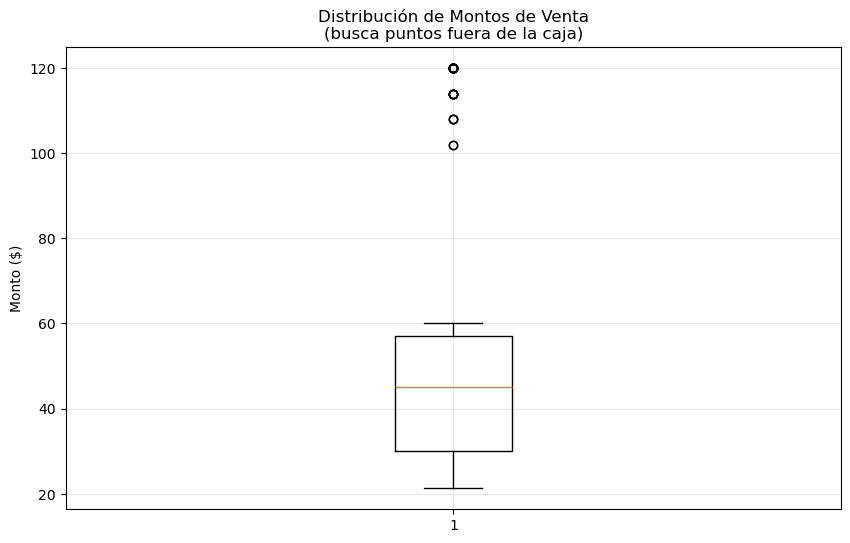

In [216]:

# Crear un "boxplot" (gráfico de caja) para monto venta 

plt.figure(figsize=(10, 6))
plt.boxplot(pre_proccessed_data['monto_venta'])
plt.title('Distribución de Montos de Venta\n(busca puntos fuera de la caja)')
plt.ylabel('Monto ($)')
plt.grid(True, alpha=0.3)
plt.show()

#### Ganancia

In [217]:
print(pre_proccessed_data['ganancia'].describe())
print(f"mediana  ${pre_proccessed_data["ganancia"].median()}")

count    380.000000
mean      30.158553
std       16.532840
min       13.250000
25%       20.000000
50%       27.000000
75%       35.000000
max       75.000000
Name: ganancia, dtype: float64
mediana  $27.0


In [218]:


q1 = pre_proccessed_data['ganancia'].quantile(0.25)
q3 = pre_proccessed_data['ganancia'].quantile(0.75)
IQR = q3 - q1

# Se definen los límites para los outliers
limite_inferior = q1 - 1.5 * IQR
limite_superior = q3 + 1.5 * IQR

# Se hallan los outliers con este filtro
outliers = pre_proccessed_data[(pre_proccessed_data['ganancia'] < limite_inferior) | 
                               (pre_proccessed_data['ganancia'] > limite_superior)]

print(f"La ganancia normal está entre ${limite_inferior:.2f} y ${limite_superior:.2f}")
print(f"Outliers encontrados: {len(outliers)}")
print(f"Los outliers representan el {(len(outliers)/len(pre_proccessed_data))*100:.2f}% de todos nuestros datos")
print(outliers["producto"].value_counts())



La ganancia normal está entre $-2.50 y $57.50
Outliers encontrados: 41
Los outliers representan el 10.79% de todos nuestros datos
producto
Pack 3 Pulseras    41
Name: count, dtype: int64


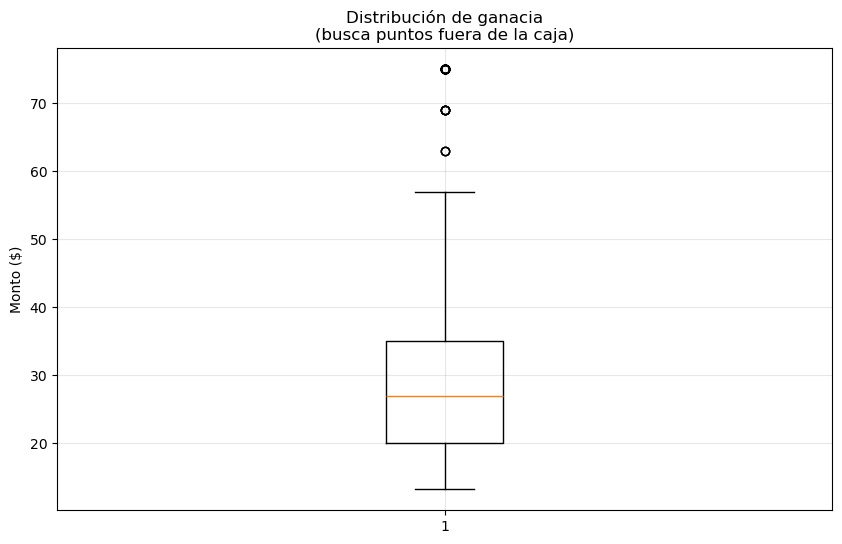

In [219]:
# Crear un "boxplot" (gráfico de caja) para ganancia

plt.figure(figsize=(10, 6))
plt.boxplot(pre_proccessed_data['ganancia'])
plt.title('Distribución de ganacia\n(busca puntos fuera de la caja)')
plt.ylabel('Monto ($)')
plt.grid(True, alpha=0.3)
plt.show()

### se identifica que el pack de 3 pulseras tienen un comportamiento o patron diferente al resto de nuestro modelo de negocio al ser un bundle y no un objeto individual

## 4. Analisis basico

Datos:
Ventas:
ciudad
Barranquilla    1901.75
Bogota          6797.25
Cali            3598.25
Cartagena       1722.75
Medellin        4421.25
Name: monto_venta, dtype: float64

Porcentaje:
ciudad
Barranquilla    10.312479
Bogota          36.858944
Cali            19.511964
Cartagena        9.341829
Medellin        23.974785
Name: monto_venta, dtype: float64



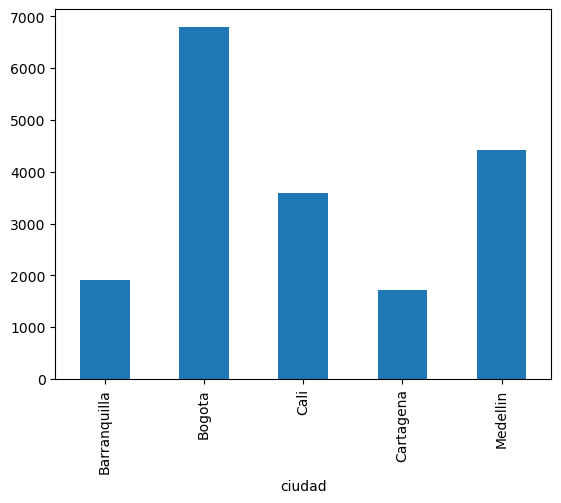

In [220]:
ventas_ciudad=pre_proccessed_data.groupby("ciudad")['monto_venta'].sum()

total_ventas = ventas_ciudad.sum()
porcentaje = (ventas_ciudad / total_ventas * 100)

print("Datos:")
print(f"Ventas:\n{ventas_ciudad}\n")
print(f"Porcentaje:\n{porcentaje}\n")

ventas_ciudad.plot(kind='bar')
plt.show()

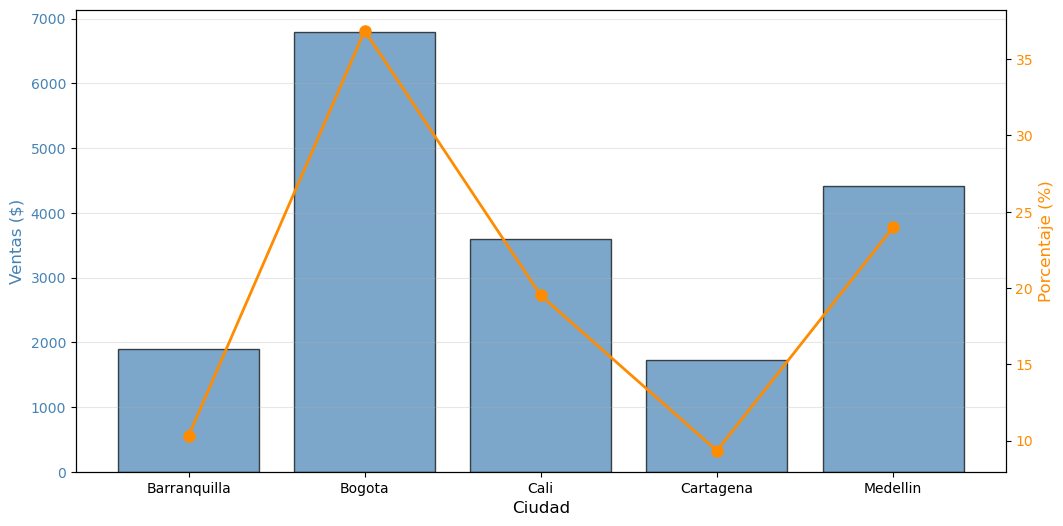

In [221]:
fig, ax1 = plt.subplots(figsize=(12, 6))
color1 = 'steelblue'
ax1.set_xlabel('Ciudad', fontsize=12)
ax1.set_ylabel('Ventas ($)', color=color1, fontsize=12)  # Etiqueta azul
ax1.bar(ventas_ciudad.index, ventas_ciudad.values, color=color1, alpha=0.7, edgecolor='black')
ax1.tick_params(axis='y', labelcolor=color1)  # Números azules
ax1.grid(axis='y', alpha=0.3)
#creación de segundo eje
ax2 = ax1.twinx()

color2 = 'darkorange'
ax2.set_ylabel('Porcentaje (%)', color=color2, fontsize=12)  # Etiqueta naranja
ax2.plot(porcentaje.index, porcentaje.values, color=color2, marker='o', 
         linewidth=2, markersize=8, label='% de ventas')
ax2.tick_params(axis='y', labelcolor=color2)  # Números naranjas


In [222]:
# Agregamos el id venta para poder evaluar venta a venta de manera idependiente evitar duplicados 

pre_proccessed_data['id_venta'] = range(1, len(pre_proccessed_data) + 1)
print(pre_proccessed_data.head())
print(pre_proccessed_data.columns)

                       fecha dia_semana  semana           producto  \
0 2023-01-03 18:19:37.180995    Tuesday       1   Pulsera NFC Plus   
1 2023-01-04 00:21:42.562036  Wednesday       1        Tarjeta NFC   
2 2023-01-04 19:06:02.586531  Wednesday       1        Tarjeta NFC   
3 2023-01-06 00:31:05.391784     Friday       1  Brazalete Premium   
4 2023-01-08 20:36:44.190016     Sunday       1        Tarjeta NFC   

   precio_unitario  descuento_pct  monto_venta  costo_unitario  ganancia  \
0               45              0         45.0              18      27.0   
1               25             10         22.5               8      14.5   
2               25              0         25.0               8      17.0   
3               60              0         60.0              22      38.0   
4               25              0         25.0               8      17.0   

   margen_pct      canal        ciudad   año  mes_numero  id_venta  
0       60.00  Instagram  Barranquilla  2023         

In [223]:
print("\n✅ PASO 2: Verificando unicidad...\n")

print(f"Total de filas: {len(pre_proccessed_data)}")
print(f"IDs únicos: {pre_proccessed_data['id_venta'].nunique()}")



✅ PASO 2: Verificando unicidad...

Total de filas: 380
IDs únicos: 380


## 4.Crear las tablas dimensionales y de facts

In [224]:
#canal
dim_canal = pd.DataFrame(pre_proccessed_data['canal'].unique(), columns=["nombre_canal"])
# Convertir a DataFrame y agregar columna ID distinta al index
dim_canal["id_canal"] = range(1, len(dim_canal) + 1)  # ID consecutivo empezando en 1

# Reordenar columnas para que id_canal aparezca primero
dim_canal = dim_canal[["id_canal", "nombre_canal"]]

print(dim_canal)

   id_canal nombre_canal
0         1    Instagram
1         2       TikTok
2         3     Referido
3         4     Facebook
4         5   Página Web
5         6     WhatsApp


In [225]:
#ciudad
dim_ciudad = pd.DataFrame(pre_proccessed_data['ciudad'].unique(), columns=["nombre_ciudad"])
# Convertir a DataFrame y agregar columna ID distinta al index
dim_ciudad["id_ciudad"] = range(1, len(dim_ciudad) + 1)  # ID consecutivo empezando en 1

# Reordenar columnas para que id_canal aparezca primero
dim_ciudad = dim_ciudad[["id_ciudad", "nombre_ciudad"]]

print(dim_ciudad)

   id_ciudad nombre_ciudad
0          1  Barranquilla
1          2        Bogota
2          3          Cali
3          4      Medellin
4          5     Cartagena


In [226]:
#producto
dim_producto = pd.DataFrame(pre_proccessed_data['producto'].unique(), columns=["nombre_producto"])
# Convertir a DataFrame y agregar columna ID distinta al index
dim_producto["id_producto"] = range(1, len(dim_producto) + 1)  # ID consecutivo empezando en 1

# Reordenar columnas para que id_canal aparezca primero
dim_producto = dim_producto[["id_producto", "nombre_producto"]]

print(dim_producto)

   id_producto    nombre_producto
0            1   Pulsera NFC Plus
1            2        Tarjeta NFC
2            3  Brazalete Premium
3            4    Pack 3 Pulseras
4            5        Llavero NFC


In [227]:
fact_ventas=pre_proccessed_data.rename(columns={'canal':'nombre_canal','producto':'nombre_producto','ciudad':'nombre_ciudad'})
print(fact_ventas)

                         fecha dia_semana  semana    nombre_producto  \
0   2023-01-03 18:19:37.180995    Tuesday       1   Pulsera NFC Plus   
1   2023-01-04 00:21:42.562036  Wednesday       1        Tarjeta NFC   
2   2023-01-04 19:06:02.586531  Wednesday       1        Tarjeta NFC   
3   2023-01-06 00:31:05.391784     Friday       1  Brazalete Premium   
4   2023-01-08 20:36:44.190016     Sunday       1        Tarjeta NFC   
..                         ...        ...     ...                ...   
375 2024-06-15 06:19:49.114114   Saturday      24  Brazalete Premium   
376 2024-06-16 19:33:56.337397     Sunday      24        Tarjeta NFC   
377 2024-06-22 03:57:48.782395   Saturday      25        Llavero NFC   
378 2024-06-22 20:09:59.101967   Saturday      25  Brazalete Premium   
379 2024-06-24 13:39:56.346359     Monday      26  Brazalete Premium   

     precio_unitario  descuento_pct  monto_venta  costo_unitario  ganancia  \
0                 45              0         45.0         

In [228]:
#cambiar de la tabla facts los valores de nombres por ids

fact_ventas=fact_ventas.merge(dim_producto[["id_producto","nombre_producto"]],on='nombre_producto').drop(columns='nombre_producto')
fact_ventas=fact_ventas.merge(dim_canal[["id_canal","nombre_canal"]],on='nombre_canal').drop(columns='nombre_canal')

fact_ventas=fact_ventas.merge(dim_ciudad[["id_ciudad","nombre_ciudad"]],on='nombre_ciudad').drop(columns='nombre_ciudad')
print(fact_ventas)

                         fecha dia_semana  semana  precio_unitario  \
0   2023-01-03 18:19:37.180995    Tuesday       1               45   
1   2023-01-04 00:21:42.562036  Wednesday       1               25   
2   2023-01-04 19:06:02.586531  Wednesday       1               25   
3   2023-01-06 00:31:05.391784     Friday       1               60   
4   2023-01-08 20:36:44.190016     Sunday       1               25   
..                         ...        ...     ...              ...   
375 2024-06-15 06:19:49.114114   Saturday      24               60   
376 2024-06-16 19:33:56.337397     Sunday      24               25   
377 2024-06-22 03:57:48.782395   Saturday      25               30   
378 2024-06-22 20:09:59.101967   Saturday      25               60   
379 2024-06-24 13:39:56.346359     Monday      26               60   

     descuento_pct  monto_venta  costo_unitario  ganancia  margen_pct   año  \
0                0         45.0              18      27.0       60.00  2023   
1

In [ ]:
#ORganizar columnas 
fact_ventas=fact_ventas[['id_venta','fecha','año','mes_numero', 'semana','dia_semana', 'precio_unitario', 'descuento_pct',
       'monto_venta', 'costo_unitario', 'ganancia', 'margen_pct', 
        'id_producto', 'id_canal', 'id_ciudad']]
print(fact_ventas)

     id_venta                      fecha dia_semana  semana  precio_unitario  \
0           1 2023-01-03 18:19:37.180995    Tuesday       1               45   
1           2 2023-01-04 00:21:42.562036  Wednesday       1               25   
2           3 2023-01-04 19:06:02.586531  Wednesday       1               25   
3           4 2023-01-06 00:31:05.391784     Friday       1               60   
4           5 2023-01-08 20:36:44.190016     Sunday       1               25   
..        ...                        ...        ...     ...              ...   
375       376 2024-06-15 06:19:49.114114   Saturday      24               60   
376       377 2024-06-16 19:33:56.337397     Sunday      24               25   
377       378 2024-06-22 03:57:48.782395   Saturday      25               30   
378       379 2024-06-22 20:09:59.101967   Saturday      25               60   
379       380 2024-06-24 13:39:56.346359     Monday      26               60   

     descuento_pct  monto_venta  costo_

## 5. Crear archivos CSV
